In [1]:
! pip install caveclient cloud-volume jinja2 seaborn meshparty vtk microviewer

In [3]:
dataset_name = 'minnie65_public'
materialization = 1300      # Required for mesh downloading

In [4]:
import numpy as np
import pandas as pd

In [5]:
from caveclient import CAVEclient

client = CAVEclient(dataset_name)
client.info.get_datastack_info()['description']

'This is the publicly released version of the minnie65 volume and segmentation. '

In [6]:
available_versions = client.materialize.get_versions()

print('Available materializations: ')
for version in available_versions:
    print(f"\tVersion {version}: {client.materialize.get_timestamp(version)}")

if materialization not in available_versions:
    print(f'Unknown materialization version: {materialization}')

if materialization != max(available_versions):
    print(f'WARNING: Not using the latest materialization version, { materialization } < { max(available_versions) }')

print(f'Using materialization v{ materialization }')
client.version = materialization

Available materializations: 
	Version 1300: 2025-01-13 10:10:01.286229+00:00
	Version 1078: 2024-06-05 10:10:01.203215+00:00
	Version 117: 2021-06-11 08:10:00.215114+00:00
	Version 661: 2023-04-06 20:17:09.199182+00:00
	Version 343: 2022-02-24 08:10:00.184668+00:00
	Version 1181: 2024-09-16 10:10:01.121167+00:00
	Version 795: 2023-08-23 08:10:01.404268+00:00
	Version 943: 2024-01-22 08:10:01.497934+00:00
	Version 1412: 2025-04-29 10:10:01.200893+00:00
	Version 1507: 2025-07-31 08:10:01.117494+00:00
	Version 1621: 2025-11-25 08:10:01.094430+00:00
Using materialization v1300


In [7]:
from cloudvolume import CloudVolume, Bbox, Vec

seg_cv = CloudVolume('precomputed://https://storage.googleapis.com/iarpa_microns/minnie/minnie65/seg_m1300', progress=False, use_https=True)
img_cv = CloudVolume('precomputed://https://storage.googleapis.com/iarpa_microns/minnie/minnie65/em', progress=True, use_https=True)

# seg_cv.cache.enabled = True
# seg_cv.cache.path = './seg_m1300'

In [8]:
from caveclient import CAVEclient
client = CAVEclient("minnie65_public")

meta = client.materialize.get_table_metadata("allen_v1_column_types_slanted_ref")
ann_res = Vec(*meta["voxel_resolution"])
seg_res = seg_cv.resolution

ann_to_seg = ann_res / seg_res
ann_to_seg

Vec(0.5,0.5,1.0, dtype=float64)

In [8]:
ann_res, seg_res

(Vec(4.0,4.0,40.0, dtype=float64), Vec(8.0,8.0,40.0, dtype=float64))

In [9]:
ct_manual_df = client.materialize.tables \
    .allen_v1_column_types_slanted_ref() \
    .query(desired_resolution=[1,1,1]) \
    .rename(columns={'target_id': 'nucleus_id'}) \
    .drop_duplicates('pt_root_id', keep=False)

ct_auto_df = client.materialize.tables \
    .aibs_metamodel_celltypes_v661() \
    .query(desired_resolution=[1,1,1]) \
    .rename(columns={'target_id': 'nucleus_id'}) \
    .drop_duplicates('pt_root_id', keep=False)

indices = ['pt_root_id', 'classification_system', 'cell_type', 'nucleus_id', 'pt_position']

ct_all_df = pd.merge(
    ct_auto_df[indices], ct_manual_df[indices], 
    on=['pt_root_id', 'nucleus_id'], 
    how='outer', 
    suffixes=['_auto', '_manual']
    )

merged_cols = ['cell_type', 'classification_system', 'pt_position']
for col in merged_cols:
    ct_all_df[col] = ct_all_df[f'{ col }_manual'].fillna(ct_all_df[f'{ col }_auto'])

ct_all_df = ct_all_df.fillna({
    f'{ col }_auto': 'unknown'    
    for col in merged_cols
})

ct_all_df = ct_all_df.fillna({
    f'{ col }_manual': 'unknown'
    for col in merged_cols
})

In [10]:
cell_info = ct_manual_df[
        (ct_manual_df['classification_system'] == 'aibs_coarse_excitatory') &
        (ct_manual_df['cell_type'] == '23P')
    ] \
    .sort_values(by='volume', ascending=False) \
    .iloc[50]

cell_info

id_ref                                               1325
created_ref              2023-03-18 14:13:22.646556+00:00
valid_ref                                            True
nucleus_id                                         258113
classification_system              aibs_coarse_excitatory
cell_type                                             23P
id                                                 258113
created                  2020-09-28 22:43:32.150344+00:00
valid                                                True
volume                                         355.082062
pt_supervoxel_id                        88181726572292650
pt_root_id                             864691135801170018
pt_position                      [681280, 531968, 809000]
bb_start_position                      [<NA>, <NA>, <NA>]
bb_end_position                        [<NA>, <NA>, <NA>]
Name: 595, dtype: object

In [11]:
center = Vec(*cell_info['pt_position']) / seg_res
size = 256
cut = Bbox(center - size//2, center + size//2).astype(int)
print(cut)
seg = seg_cv.image.download(cut, mip=0)
img = img_cv.image.download(cut, mip=0)

Bbox([85032, 66368, 20097],[85288, 66624, 20353], dtype=np.int64, unit='vx')


Decompressing: 100%|██████████| 81/81 [00:00<00:00, 918.58it/s]


In [12]:
print(f'Center of segmentation: {seg[size//2, size//2, size//2]}')
print(f'Expected cell ID: { cell_info['pt_root_id'] }')

Center of segmentation: [864691135801170018]
Expected cell ID: 864691135801170018


In [13]:
# from microviewer import hyperview
# hyperview(img, seg)

In [13]:
ct_all_neurons = ct_all_df[
    ~ct_all_df['classification_system'].isin([
        'nonneuron',
        'unknown',
        'aibs_coarse_unclear'
    ])
]

positions = np.vstack(ct_all_neurons['pt_position'].to_numpy())

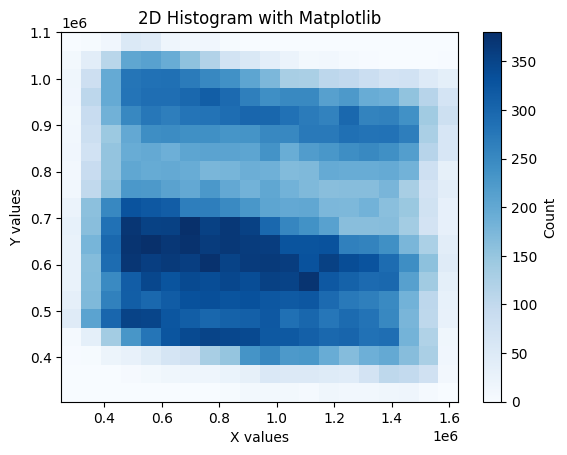

In [12]:
import matplotlib.pyplot as plt

plt.hist2d(positions[:,0], positions[:,1], bins=20, cmap='Blues')
plt.colorbar(label='Count')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('2D Histogram with Matplotlib')
plt.show()

In [13]:
np.min(positions[:,2]), np.max(positions[:,2])

(np.int64(603080), np.int64(1105200))

In [14]:
H, xedges, yedges = np.histogram2d(positions[:,0], positions[:,1])
max_x, max_y = np.unravel_index(np.argmax(H), H.shape)
max_x_coord = xedges[max_x]
max_y_coord = yedges[max_y]

max_x_coord, max_y_coord

(np.float64(665337.6000000001), np.float64(623104.0))

In [68]:
depth_nm = 200 * 1e3
depth_vx = depth_nm / seg_res[2]

# arr_size = 4 * pow(1024, 3)
# lateral_vx = np.cbrt(5 * (arr_size / 8))
# depth_vx = lateral_vx / 5

depth_vx = 200
lateral_vx = 5 * depth_vx

depth_nm = depth_vx * seg_res[2]
lateral_nm = lateral_vx * seg_res[0]

print(f'Lateral (nm): {lateral_nm}')

cut_ann = Bbox(
    Vec(
        max_x_coord - lateral_nm / 2,
        max_y_coord - lateral_nm / 2,
        np.min(positions[:,2])
    ),
    Vec(
        max_x_coord + lateral_nm / 2,
        max_y_coord + lateral_nm / 2,
        np.min(positions[:,2]) + depth_nm
    )
)
cut_seg = cut_ann / seg_res
cut_seg = cut_seg.astype(int)
cut_seg

Lateral (nm): 8000.0


Bbox([82667, 77388, 15077],[83667, 78388, 15277], dtype=np.int64, unit='vx')

In [69]:
seg = seg_cv.image.download(cut_seg, mip=0)

Decompressing: 100%|██████████| 567/567 [00:00<00:00, 16972.14it/s]


In [70]:
depth_vx

200

In [ ]:
desired_res = Vec(100, 100, 100)

In [32]:
def weights_for_1d_voxel_downscaling(
        p: int,
        dx_in,
        dx_out
    ):

    assert dx_in > 0 and dx_out > 0

    # Output voxel interval
    x0 = p * dx_out
    x1 = x0 + dx_out

    i_start = int(np.floor(x0 / dx_in))
    i_end = int(np.ceil(x1 / dx_in))
    idx = np.arange(i_start, i_end + 1, dtype=np.int64)

    in_left = idx * dx_in
    in_right = in_left + dx_in

    overlap = np.minimum(in_right, x1) - np.maximum(in_left, x0)
    overlap = np.maximum(overlap, 0.0)

    idx = idx[overlap > 1e-12]
    overlap = overlap[overlap > 1e-12]

    w = overlap / dx_in

    return idx, w

idx, w = weights_for_1d_voxel_downscaling(0, 8, 100)
idx, w

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 array([1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 0.5]))

In [17]:
def resample(V, vx_coord, din, dout):
    Nx, Ny, Nz = V.shape

    i, j ,k = vx_coord
    dx_in, dy_in, dz_in = din
    dx_out, dy_out, dz_out = dout

    idx_x, wx = weights_for_1d_voxel_downscaling(i, dx_in, dx_out)
    idx_y, wy = weights_for_1d_voxel_downscaling(i, dy_in, dy_out)
    idx_z, wz = weights_for_1d_voxel_downscaling(i, dz_in, dz_out)

    block = V[np.ix_(idx_x, idx_y, idx_z)]
    W = wx[:, None, None] * wy[None, :, None] * wz[None, None, :]
    val = float(np.sum(block * W))

    return val

In [18]:
n = 100
orig = np.ones((n, n, n//5)) * (8 / 100) * (8 / 100) * (40 / 100)
resample(orig, (0, 1, 1), (8, 8, 40), (100, 100, 100))

1.0

In [26]:
def range_helper(p, origin, dx_in, dx_out):
    x0 = origin + (p * dx_out)
    x1 = x0 + dx_out

    i_start = int(np.floor(x0 / dx_in))
    i_end = int(np.ceil(x1 / dx_in))
    idx = np.arange(i_start, i_end, dtype=np.int64)
    
    return (i_start, i_end)
    # return idx


def compute_new_voxel(seg, seg_res, origin, vx_coord, vx_res, ct_df):
    
    idx_x = range_helper(vx_coord[0], origin[0], seg_res[0], vx_res[0])
    idx_y = range_helper(vx_coord[1], origin[1], seg_res[1], vx_res[1])
    idx_z = range_helper(vx_coord[2], origin[2], seg_res[2], vx_res[2])

    cut = Bbox(
        Vec(idx_x[0], idx_y[0], idx_z[0]),
        Vec(idx_x[1], idx_y[1], idx_z[1]),
    )

    block = seg.image.download(cut, mip=0)

    # block = seg[np.ix_(idx_x, idx_y, idx_z)]

    unique_ids = np.unique(block)

    val = 0
    for uid in unique_ids:
        if uid not in ct_df['pt_root_id'].values: continue

        neuron_image = np.zeros(block.shape[:-1])
        mask = np.any(block == uid, axis=-1)
        neuron_image[mask] = 1

        val += resample(neuron_image, (0, 0, 0), seg_res, vx_res)

    return val

In [ ]:
# origin = Vec(max_x_coord, max_y_coord, np.min(positions[:,2]))
origin = Vec(681280, 531968, 809000)
origin = origin.astype(int)
block = compute_new_voxel(seg_cv, seg_res, origin, (1000, 1, 1), (100, 100, 100), ct_all_df)
block

0

In [28]:
from tqdm import tqdm

vx_sz = 1e3

im = np.zeros((64, 64))
for idx, _ in tqdm(np.ndenumerate(im), total=im.size):
    im[idx] = compute_new_voxel(seg_cv, seg_res, origin, (*idx, 0), (vx_sz, vx_sz, vx_sz), ct_all_df)

100%|██████████| 4096/4096 [20:14<00:00,  3.37it/s]


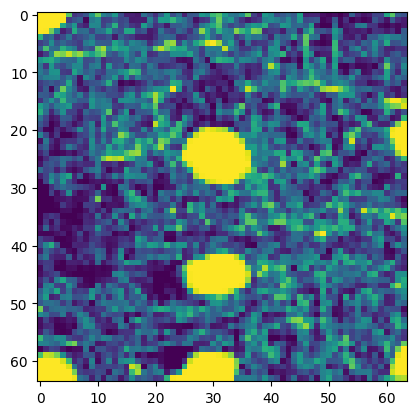

In [29]:
plt.imshow(im)

In [30]:
def resample(V, vx_coord, din, dout):
    Nx, Ny, Nz = V.shape

    i, j ,k = vx_coord
    dx_in, dy_in, dz_in = din
    dx_out, dy_out, dz_out = dout

    idx_x, wx = weights_for_1d_voxel_downscaling(i, dx_in, dx_out)
    idx_y, wy = weights_for_1d_voxel_downscaling(i, dy_in, dy_out)
    idx_z, wz = weights_for_1d_voxel_downscaling(i, dz_in, dz_out)

    block = V[np.ix_(idx_x, idx_y, idx_z)]
    W = wx[:, None, None] * wy[None, :, None] * wz[None, None, :]
    val = float(np.sum(block * W))

    return val


def range_helper(p, dx_in, dx_out):
    x0 = p * dx_out
    x1 = x0 + dx_out

    i_start = int(np.floor(x0 / dx_in))
    i_end = int(np.ceil(x1 / dx_in))
    idx = np.arange(i_start, i_end, dtype=np.int64)
    
    # return (i_start, i_end)
    return idx


def compute_new_voxel(seg, seg_res, vx_coord, vx_res, ct_df):
    
    idx_x = range_helper(vx_coord[0], seg_res[0], vx_res[0])
    idx_y = range_helper(vx_coord[1], seg_res[1], vx_res[1])
    idx_z = range_helper(vx_coord[2], seg_res[2], vx_res[2])

    # cut = Bbox(
    #     Vec(idx_x[0], idx_y[0], idx_z[0]),
    #     Vec(idx_x[1], idx_y[1], idx_z[1]),
    # )

    # block = seg.image.download(cut, mip=0)

    block = seg[np.ix_(idx_x, idx_y, idx_z)]

    unique_ids = np.unique(block)

    val = 0
    for uid in unique_ids:
        if uid not in ct_df['pt_root_id'].values: continue

        neuron_image = np.zeros(block.shape[:-1])
        mask = np.any(block == uid, axis=-1)
        neuron_image[mask] = 1

        val += resample(neuron_image, (0, 0, 0), seg_res, vx_res)

    return val

In [30]:
arr_size = 4 * pow(1024, 3)
lateral_vx = np.cbrt(5 * (arr_size / 8))
depth_vx = lateral_vx / 5

print(lateral_vx, depth_vx)

1389.7818196965923 277.95636393931846


In [20]:
from math import lcm

dx_in = int(seg_res[0])
dx_out = 100

dz_in = int(seg_res[2])
dz_out = 100

n_lat = lcm(dx_in, dx_out) / dx_in
n_depth = lcm(dz_in, dz_out) / dz_in

n_lat, n_depth

(25.0, 5.0)

In [26]:
from tqdm import tqdm

###############################
# NOTE: MUST BE EDGE ALIGNED!!!
###############################

# TODO: Update to be edge aligned (only memory-based sizing part)
# arr_size = 4 * pow(1024, 3)
# lateral_vx = np.cbrt(5 * (arr_size / 8))
# depth_vx = lateral_vx / 5

depth_vx = 8 * n_depth                  # vx
lateral_vx = 240 * n_lat                # vx

origin = Vec(681280, 531968, 809000)    # nm
origin = origin.astype(int)             # nm

print(f'Estimated array size: {(lateral_vx * lateral_vx * depth_vx * 8) / pow(1024, 3) :.2f} GB')

depth_nm = depth_vx * seg_res[2]
lateral_nm = lateral_vx * seg_res[0]

def compute_supervoxel(seg, seg_res, seg_origin, svx_coord, svx_size, vx_res, ct_df):
    a = seg_origin + Vec(
        svx_size[0] * svx_coord[0],
        svx_size[1] * svx_coord[1],
        svx_size[2] * svx_coord[2]
    )
    b = a + Vec(
        svx_size[0],
        svx_size[1],
        svx_size[2]
    )
    cut = Bbox(a, b) / seg_res
    cut = cut.astype(int)

    block = seg.image.download(cut, mip=0)

    nx = int(svx_size[0] / vx_res[0])
    ny = int(svx_size[1] / vx_res[1])
    nz = int(svx_size[2] / vx_res[2])

    svx = np.zeros((nx, ny, nz))
    print(svx.shape)

    for idx, _ in tqdm(np.ndenumerate(svx), total=svx.size):
        svx[idx] = compute_new_voxel(block, seg_res, idx, vx_res, ct_df)

    return svx

Estimated array size: 10.73 GB


In [27]:
svx = compute_supervoxel(seg_cv, seg_res, origin, (0, 0, 0), (lateral_nm, lateral_nm, depth_nm), (100, 100, 100), ct_all_df)
plt.imshow(svx[:,:,0])

KeyboardInterrupt: 

In [28]:
from pathlib import Path
import os

# TODO: Save other metadata (coordinate systems, sources, etc) to a JSON
# TODO: Compare existing JSON with current JSON before modifying store
def memoize_supervoxel(folder, seg, seg_res, seg_origin, svx_coord, svx_size, vx_res, ct_df, flush=False):
    filename = f'svx_{svx_coord[0]}_{svx_coord[1]}_{svx_coord[2]}.npy'
    
    folder = Path(folder)
    if folder.exists() == False:
        os.makedirs(str(folder.absolute()))

    filepath = folder.joinpath(filename)
    if filepath.exists():
        if flush:
            os.remove(str(filepath.absolute()))
        else:
            return np.load(str(filepath.absolute()))
        
    svx = compute_supervoxel(seg, seg_res, seg_origin, svx_coord, svx_size, vx_res, ct_df)
    np.save(filepath, svx)

    return svx

In [37]:
depth_vx = 8 * n_depth                  # vx
lateral_vx = 100 * n_lat                # vx

print(f'Estimated array size: {(lateral_vx * lateral_vx * depth_vx * 8) / pow(1024, 3) :.2f} GB')

depth_nm = depth_vx * seg_res[2]
lateral_nm = lateral_vx * seg_res[0]

origin = Vec(681280, 531968, 809000)    # nm
origin = origin.astype(int)             # nm

svx = memoize_supervoxel('./svx01', seg_cv, seg_res, origin, (0, 0, 0), (lateral_nm, lateral_nm, depth_nm), (100, 100, 100), ct_all_df)

Estimated array size: 1.86 GB


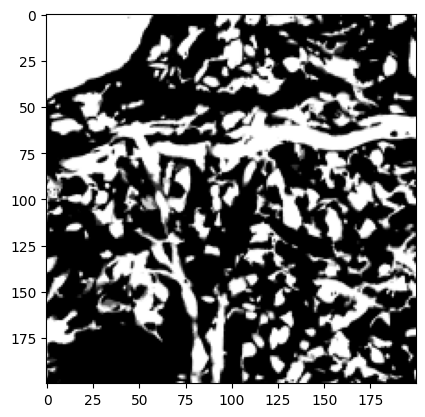

: 

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(svx[:,:,0], cmap='gray')

In [50]:
np.any(block == 864691134966128927)

VolumeCutout(False)

In [ ]:
# Blood Vessel ID: 864691134966128927